### Множественная линейная регрессия на чистых данных

#### Цель работы

Познакомиться с основными приемами работы с множественными регрессионными моделями с использованием библиотеки sklearn.

#### Содержание работы

1. Ваша задача - построить предиктивную модель предсказания целевой переменной в зависимости от значения нескольких факторов (признаков).
2. Загрузите датасет из приложения. Вам понадобится два файла - отдельно с признаками (помечен x) и значениями целевой переменной (помечен y). Файлы не содержат заголовков столбцов и строк. Выведите первые строки датасета.
3. Сделайте количественное описание датасета: количество точек данных, признаков, статистику по каждому признаку.
Для целевой и каждого из признаков постройте парную регрессионную модель. Визуализируйте линию регрессии и исходные данные на графике. При помощи коэффициентов оцените силу связи.
Постройте модель множественной линейной регрессии целевой переменной от всех показателей. Оцените качество регрессии, сделайте вывод.


Для начала работы как всегда выполним стандартный импорт необходимых библиотек:

In [292]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Теперь мы можем приступить к чтению данных. Для этой работы представлено сразу 50 однотипных датасетов. Мы для примера возьмем самый первый (с названием "0"). Читать данные можно многими способами, но мы воспользуемся самым простым чтением по URL:

In [293]:
x = pd.read_csv("data/1_x.csv")

In [294]:
x.head()

,1.5998646673071175,0.34059791776594267,-0.6033998233687305,0.15058611793183632,-0.2096765504328273,0.9550448072396549,0.347682255109066
0,1.472656,0.466832,-1.947130,0.625906,0.589354,0.753521,-2.138552
1,0.279378,-1.717121,0.251069,0.730013,0.301801,-0.206711,0.894811
2,0.450771,1.133196,-0.294028,-2.595338,0.313911,1.953527,0.359938
3,1.507042,0.932115,-0.789549,1.043712,-1.404000,-0.124354,-0.921117
4,-0.793739,-1.249947,-0.048617,2.050793,-0.206069,-1.880998,0.596198


Если выполнить этот код то при внимательном рассмотрении можно заметить одну ошибку. Первая строка данных была помещена в заголовки строк. Чаще всего в файле с данными первая строка как раз и содержит заголовки, поэтому такое поведение чаще бывает полезным. Но в нашем случае датасет не содержит заголовков. Поэтому при чтении надо это учесть:

In [295]:
x = pd.read_csv("data/1_x.csv",
                header=None)
y = pd.read_csv("data/1_y.csv",
                header=None)

Теперь данные прочтены верно. Но лучше еще раз в этом убедиться, выведя часть датасета на экран.

При работе с данными важно понимать размер данных и то, как они располагаются в струкруре, то есть в переменных. Выведем количественные параметры датаета:

In [296]:
x.head()

,0,1,2,3,4,5,6
0,1.599865,0.340598,-0.603400,0.150586,-0.209677,0.955045,0.347682
1,1.472656,0.466832,-1.947130,0.625906,0.589354,0.753521,-2.138552
2,0.279378,-1.717121,0.251069,0.730013,0.301801,-0.206711,0.894811
3,0.450771,1.133196,-0.294028,-2.595338,0.313911,1.953527,0.359938
4,1.507042,0.932115,-0.789549,1.043712,-1.404000,-0.124354,-0.921117


In [297]:
y.head()

,0
0,101.507602
1,-65.305680
2,152.189336
3,-109.702103
4,-11.188624


In [298]:
x.shape, y.shape

((125, 7), (125, 1))

Здесь мы должны заметить сразу несколько вещей. Во-первых, обе переменные представлют собой двумерные массивы. Точнее они представлены в виде DataFrame. В матрице атрибутов (X) 125 строк и 7 столбцов. Это значит, что в датасете описаны 125 объектов и у каждого есть 7 признаков. Или, можно сказать, что в X 7 векторов признаков по 125 значенй. Важно то, что по строкам у нам объекты, а по столбцам - атрибуты (характеристики).

В целевой переменной (Y) у нас один стоблец и 125 строчек. Очень важно, чтобы количество строк в обоих переменных совпадало. Фактически, Y пердставляет собой вектор-столбец. То есть один единственный атрибут описан для 125 объектов.

In [299]:
x.describe()

,0,1,2,3,4,5,6
count,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000
mean,-0.046701,0.173034,0.049015,-0.005271,-0.095981,-0.107452,-0.056552
std,0.933281,0.928898,0.984631,1.000964,1.087336,0.928998,1.064615
min,-2.190258,-2.358885,-2.081062,-2.898741,-2.841371,-2.907825,-2.138552
25%,-0.775334,-0.429173,-0.657021,-0.685499,-0.869306,-0.672357,-0.936561
50%,0.030645,0.204892,-0.048617,0.054299,-0.102158,-0.174373,0.062705
75%,0.545665,0.755290,0.804735,0.659364,0.689661,0.531740,0.596198
max,2.092059,3.142216,2.272042,2.065050,2.660842,2.086050,3.026906


In [300]:
y.describe()

,0
count,125.000000
mean,-10.905182
std,135.622216
min,-288.468951
25%,-115.832866
50%,1.582923
75%,92.343694
max,293.947002


Статистический анализ (методы describe()) показывает, что признаки имеют различные диапазоны значений (от -2.9 до 3.14), а целевая переменная варьируется от -288.5 до 293.9. 

Такое представление данных подходит для начала машинного обучения. Все, что нужно совпадает. Теперь мы можем приступать к созданию и обучению модели. Для этого сначала импортируем нужный объект из библиотеки scikit-learn:

In [301]:
from sklearn.linear_model import LinearRegression

In [302]:
binary = LinearRegression()

Для начала мы построим модель парной регрессии от одного из признаков в датасете. Для этого из матрицы атрибутов нужно вытащить один столбец. Можно сделать это так: x[1]. Напоминаем, что в DataFrame по умолчанию индексация происходит по столбцам. Но тут возникает проблема. Дело в том, что все библиотечные средства предполагают, что X - это двумерный массив. А взятие одного столбца возвращает не DataFrame, а Series - одномерный массив. Превратить его в двумерный можно многими разными способами, но в Pandas можно взять несколкьо столбцов из датафрейма. Такая операция вернет всегда именно датафрейм. А нам нужен датафрейм из одного столбца. Сделать это можно так: x[[1]]. Итак, возьмем один столбец и обучим парную регрессию его с целевой переменной:

In [303]:
binary.fit(x[[1]], y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [304]:
binary.coef_

array([[0.82714395]])

In [305]:
binary.predict(x[[1]])

array([[-10.7665824 ],
       [-10.66216885],
       [-12.46861188],
       [-10.1109895 ],
       [-10.27731243],
       [-12.08219209],
       [-11.04172683],
       [ -9.42985013],
       [-11.04699375],
       [-10.5807694 ],
       [-10.42357229],
       [-10.56836776],
       [ -8.44924107],
       [ -9.76159855],
       [-10.77664556],
       [-10.64988592],
       [-11.0776237 ],
       [-10.31228117],
       [ -9.97322043],
       [-10.58817296],
       [-11.41187787],
       [-10.07547305],
       [-10.38510413],
       [ -9.64986815],
       [-10.57985183],
       [-10.79738539],
       [ -9.7309872 ],
       [ -9.86184072],
       [-11.40329371],
       [-12.44289149],
       [-11.19289547],
       [-11.36730644],
       [-10.44423367],
       [-11.80313646],
       [-10.07656595],
       [-10.43413816],
       [-11.61384744],
       [-11.38015835],
       [-11.11093323],
       [-12.78840187],
       [-11.42336447],
       [-11.79109223],
       [-11.21530966],
       [-10

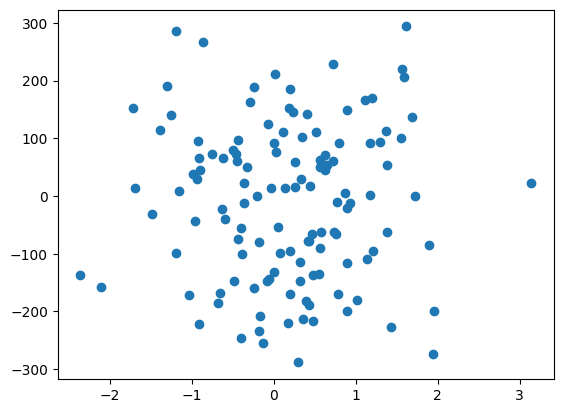

In [306]:
plt.scatter(x[1], y)

Для построения линии модели просто использовать plot вот так: plt.plot(x[1], y) будет уже неправильно. Лучше построить равномерное распределение точек от минимального до максимального по X и уже по нему расчитать модельные значения:

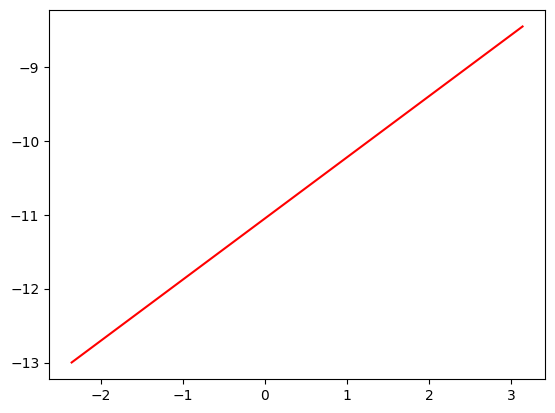

In [307]:
xx = np.linspace(x[1].min(), x[1].max(), 100).reshape((-1, 1))
plt.plot(xx, binary.predict(xx), c='r')

#### Парные регрессии для признаков

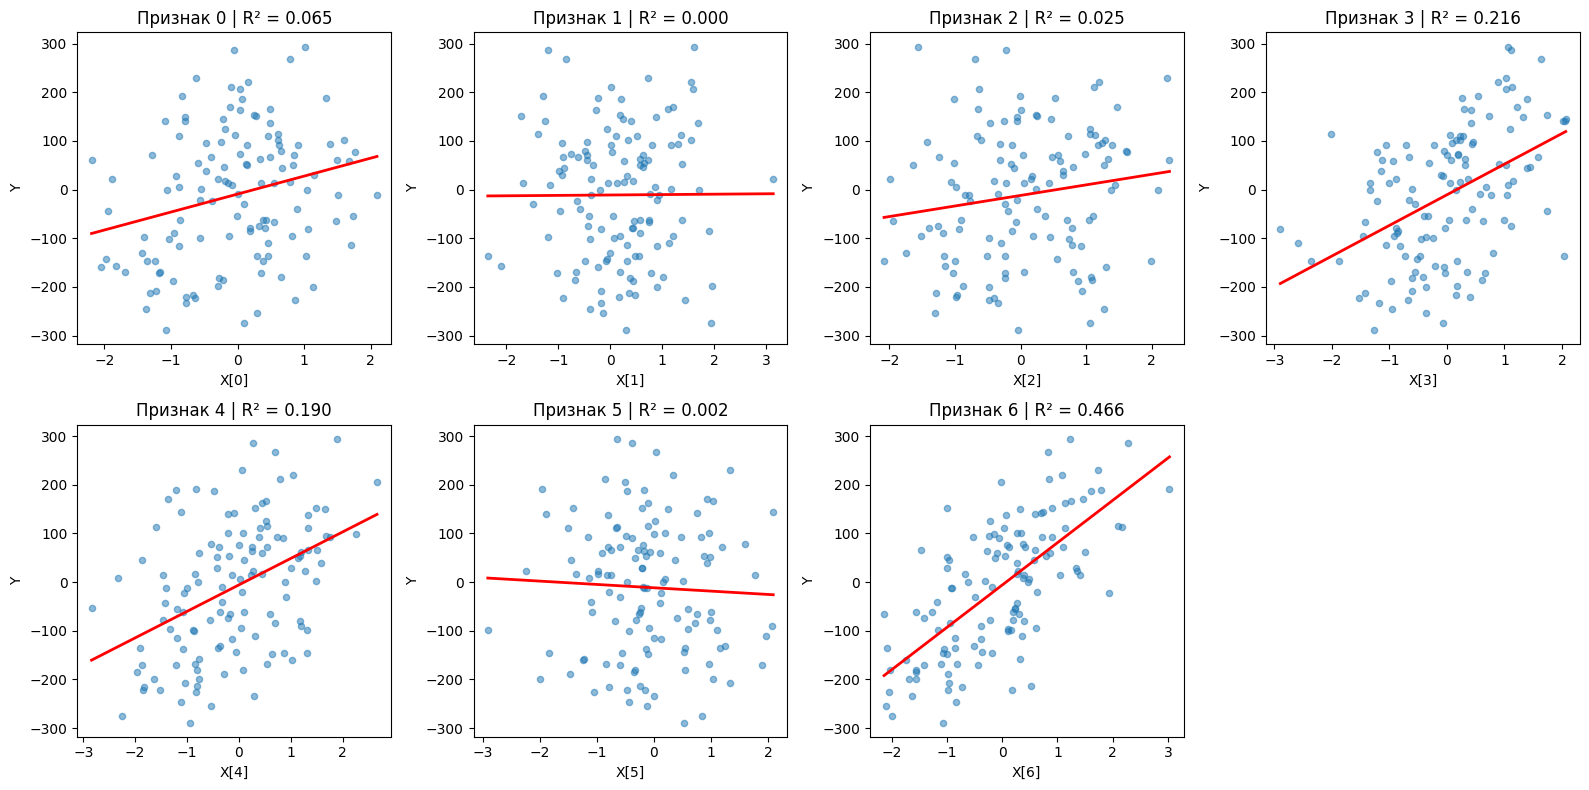

In [308]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(7):
    model = LinearRegression()
    model.fit(x[[i]], y)
    axes[i].scatter(x[i], y, alpha=0.5, s=20)
    xx = np.linspace(x[i].min(), x[i].max(), 100).reshape(-1, 1)
    axes[i].plot(xx, model.predict(xx), 'r-', linewidth=2)
    axes[i].set_title(f'Признак {i} | R² = {model.score(x[[i]], y):.3f}')
    axes[i].set_xlabel(f'X[{i}]')
    axes[i].set_ylabel('Y')

axes[7].axis('off')
plt.tight_layout()
plt.show()

Лучшая парная модель — у признака X[6] с R² = 0.466. Это означает, что данный признак объясняет лишь 46.6% дисперсии целевой переменной, что является недостаточным для качественного прогнозирования.

Худшая парная модель — у признака X[1] с R² = 0 (практически ноль). Связь между этим признаком и целевой переменной отсутствует.

Ни один из признаков по отдельности не обеспечивает приемлемого качества предсказания. Целевая переменная имеет сложную, многофакторную зависимость, которую невозможно описать с помощью одного признака.

#### Множественная линейная регрессия

In [309]:
multiple = LinearRegression()
multiple.fit(x, y)
print("Коэффициенты:", multiple.coef_[0])
print("Intercept:", multiple.intercept_[0])
print("R² =", multiple.score(x, y))

Коэффициенты: [51.02147295 -0.26872966 23.76334279 69.95555491 57.05175017  0.39731156
 82.01281498]
Intercept: 0.8846278267171002
R² = 0.9950477220889814


Результаты:
Коэффициент детерминации R² = 0.995048 

Свободный член (intercept) = 0.884628

Сравнение с парными моделями:

Лучшая парная модель дала R² = 0.466

Множественная модель дала R² = 0.995

Вывод: Множественная регрессия объясняет 99.5% дисперсии целевой переменной, что является отличным результатом. Это подтверждает, что целевая переменная действительно зависит от комбинации всех семи признаков, а не от какого-либо одного. Совместное использование факторов позволяет построить высокоточную прогнозную модель.

#### Диагностический график (предсказанные | реальные)

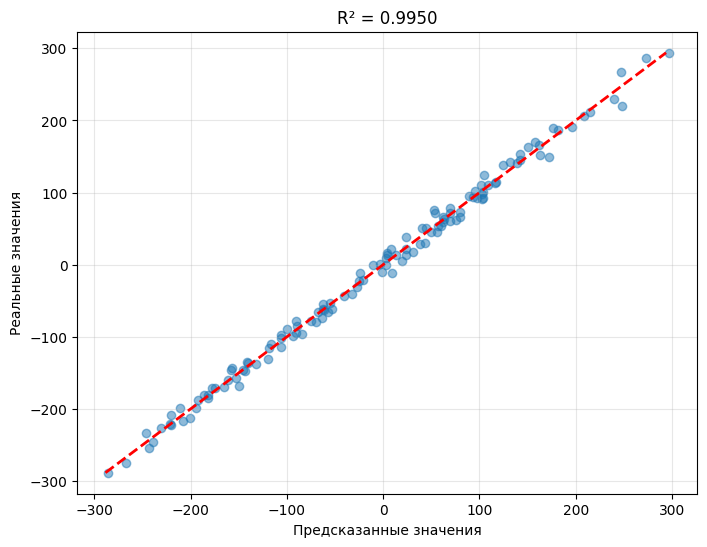

In [310]:
y_pred = multiple.predict(x)
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title(f'R² = {multiple.score(x, y):.4f}')
plt.grid(True, alpha=0.3)
plt.show()

Точки плотно сгруппированы вдоль идеальной прямой (пунктирная красная линия), что визуально подтверждает высокое качество модели и отсутствие систематической ошибки в предсказаниях.

### Контрольные вопросы

**1. Как должны выглядеть данные для модели машинного обучения?**  
Данные должны быть представлены в виде таблицы (DataFrame), где строки — это объекты (наблюдения), а столбцы — признаки. Целевая переменная (Y) выделяется отдельно. Все значения должны быть числовыми, пропуски должны быть обработаны. Для линейной регрессии желательна нормализация признаков, но не обязательна.

**2. В чем физический смысл коэффициентов линейной регрессии?**  
Коэффициент при признаке показывает, на сколько единиц изменится целевая переменная при увеличении этого признака на единицу, при условии что остальные признаки остаются неизменными. Знак коэффициента указывает направление связи (плюс — прямая, минус — обратная).

**3. Чем множественная регрессия отличается от парной?**  
Парная регрессия использует один признак для предсказания целевой переменной. Множественная — два и более признаков одновременно. Множественная регрессия позволяет учитывать совместное влияние факторов и обычно дает более точные прогнозы, если зависимость многофакторная.

**4. Какую функцию ошибки использует модель линейной регрессии?**  
Модель LinearRegression в sklearn минимизирует сумму квадратов остатков (RSS — Residual Sum of Squares), что эквивалентно минимизации среднеквадратичной ошибки (MSE). Это делается аналитически методом наименьших квадратов.

**5. Какие метрики эффективности можно применять для оценки регрессионных моделей?**  
R² (коэффициент детерминации) — доля дисперсии, объяснённая моделью.

MAE (средняя абсолютная ошибка) — среднее абсолютное отклонение.

MSE (среднеквадратичная ошибка) — штрафует большие ошибки сильнее.

RMSE (корень из MSE) — в единицах целевой переменной.

MAPE (средняя абсолютная процентная ошибка) — относительная ошибка.

**6. Какие еще регрессоры есть в библиотеке sklearn?**  
Помимо LinearRegression, в sklearn есть:

Ridge (гребневая регрессия с L2-регуляризацией)

Lasso (L1-регуляризация, обнуляет коэффициенты)

ElasticNet (комбинация L1 и L2)

SVR (support vector regression)

DecisionTreeRegressor, RandomForestRegressor, GradientBoostingRegressor — деревья и ансамбли

KNeighborsRegressor и тд.

**7. Почему для визуализации модели нельзя использовать предсказанные значения по датасету?**  
Потому что предсказания на том же датасете, на котором модель обучалась, дают оптимистичную оценку качества (модель может запомнить данные, а не обобщить). Для реальной оценки нужно использовать отложенную выборку (тестовый набор) или кросс-валидацию. Визуализация «предсказанные vs реальные» строится на тестовых данных, чтобы увидеть, насколько модель ошибается на новых примерах.